# Importing Libraries
This code was based on the [Transfer Learning for Computer Vision Tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) by [Sasank Chilamkurthy](https://chsasank.com/), released under a BSD license.

In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt

from PIL import Image
from tempfile import TemporaryDirectory
from torch.utils.data import Dataset
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
import torch.nn.functional as F


def train_model(model, criterion, optimizer, scheduler, dloaders, save_dir, num_epochs=25):
    best_acc = 0.0
    pbar = tqdm(range(num_epochs))

    for epoch in pbar:
        results = {"train": None, "val": None}

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)

                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            results[phase] = f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}'

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), save_dir)

        pbar.set_description(f'{results["train"]} {results["val"]}')

    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(torch.load(save_dir, weights_only=True))
    return model

def visualize_model(model, dloaders, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dloaders['val']):

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]][0] if len(class_names[preds[j]])>1 else class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

def evaluate(model, dataloader):
    running_corrects = 0.0
    printed = False

    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(dataloader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        if not printed:
            print(f"Input Shape: {inputs.shape}")
            printed = True

        with torch.no_grad():
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

        running_corrects += torch.sum(preds == labels.data)

        # store for f1 score
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = running_corrects.double() / dataset_sizes["val"]

    f1 = f1_score(all_labels, all_preds, average="macro")

    return {"Accuracy":acc.item(),
            "F1Score": f1}


def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated



cudnn.benchmark = True
plt.ion()   # interactive mode

# Initializing Imagenette Dataset



Using cuda device


100%|██████████| 1.56G/1.56G [00:31<00:00, 48.7MB/s]


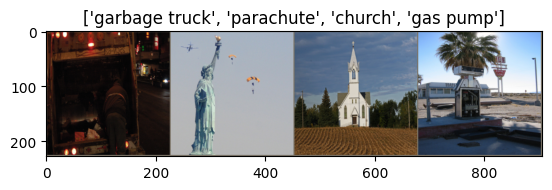

In [ ]:
factor = 0.5
image_size = 448
size = [int(image_size*factor)]*2
interp_size = [image_size]*2
patch_size = 32
batch_size = 64


data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


data_transforms_interp = {
    'train': transforms.Compose([
        transforms.Resize(interp_size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(interp_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

class TransformDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getattr__(self, name):
      return getattr(self.dataset, name)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

data = {x: datasets.Imagenette( root="/content/", split=x, size="full", download=True, transform=None) for x in ['train', 'val']}

image_datasets = {x: TransformDataset(data[x], data_transforms[x])
                  for x in ['train', 'val']}

image_datasets_interp = {x: TransformDataset(data[x], data_transforms_interp[x])
                  for x in ['train', 'val']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size,
                                             shuffle=True, num_workers=2) for x in ['train', 'val']}

dataloaders_interp = {x: torch.utils.data.DataLoader(image_datasets_interp[x], batch_size=batch_size//2,
                                             shuffle=True, num_workers=2) for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes




# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:4])
classes = classes[:4]

imshow(out, title=[class_names[x][0] if len(class_names)>1 else class_names[x] for x in classes])

# Interpolation Method

In [ ]:
def get_leaf_modules(model):
    leaf_modules = []

    for module in model.modules():  # recursive
        # A leaf has no children
        if len(list(module.children())) == 0:
            leaf_modules.append(module)

    return leaf_modules

def interp(model_interp, factor):
  sqrt_factor = int(np.sqrt(factor))
  model_interp = copy.deepcopy(model_interp)
  named_modules = get_leaf_modules(model_interp)
  for index, module in enumerate(named_modules):
    if isinstance(module, torch.nn.Conv2d):
      name = "Conv2d"
      print("Before", name, module.weight.shape, module.stride)
      orishape = module.weight.shape[-2:]
      size = [sqrt_factor*x for x in orishape]
      k = np.prod(orishape)/np.prod(size)
      interp_weight = F.interpolate(module.weight,
                                    size=size, mode="bicubic") * k
      module.weight.data = interp_weight
      module.stride = (size[0], size[1])
      print("After", name, module.weight.shape, module.stride)
  return model_interp


# Model Declaration

In [ ]:
save_dir = "vit.pt"

model_ft = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

num_ftrs = model_ft.heads.head.in_features
model_ft.heads.head = nn.Linear(num_ftrs, len(class_names))
# # model_ft.avgpool = nn.Identity()

model_ft = model_ft.to(device)
model_bak = copy.deepcopy(model_ft)
model_bak_interp = interp(model_bak, 4)
model_bak_interp.image_size = image_size
model_bak_interp.patch_size = patch_size

criterion = nn.CrossEntropyLoss()

# # Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# # Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
print(f"Base accuracy: {evaluate(model_ft, dataloaders["val"])}")
print(f"Base interp accuracy: {evaluate(model_bak_interp, dataloaders_interp["val"])}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 91.0MB/s]


Before Conv2d torch.Size([768, 3, 16, 16]) (16, 16)
After Conv2d torch.Size([768, 3, 32, 32]) (32, 32)


  0%|          | 0/62 [00:00<?, ?it/s]

Input Shape: torch.Size([64, 3, 224, 224])
Base accuracy: {'Accuracy': 0.10547770700636942, 'F1Score': 0.09231646939398722}


  0%|          | 0/123 [00:00<?, ?it/s]

Input Shape: torch.Size([32, 3, 448, 448])
Base interp accuracy: {'Accuracy': 0.10802547770700636, 'F1Score': 0.09535062375900931}


# Training the Model

In [ ]:
import gc

del model_bak, model_bak_interp
gc.collect()

torch.cuda.empty_cache()

model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,dataloaders, save_dir,
                       num_epochs=5)

# Load the Trained Model

In [ ]:
model_ft.load_state_dict(torch.load(save_dir, weights_only=True))
model_ft.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

# Visualize the Dataset

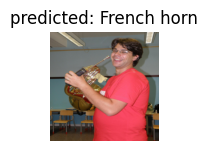

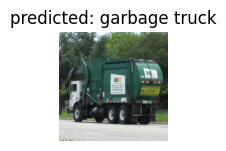

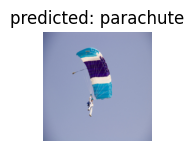

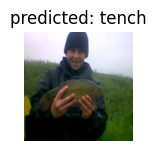

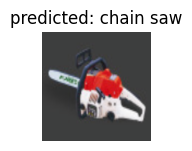

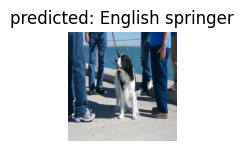

In [ ]:
visualize_model(model_ft, dataloaders)

# Evaluate Interpolated vs Trained Model

In [ ]:
print(f"Base model accuracy: {evaluate(model_ft, dataloaders["val"])}")
model_interp = interp(model_ft, 4)
model_interp.image_size = image_size
model_interp.patch_size = patch_size
print(f"Interpolated model accuracy: {evaluate(model_interp, dataloaders_interp["val"])}")

  0%|          | 0/62 [00:00<?, ?it/s]

Input Shape: torch.Size([64, 3, 224, 224])
Base model accuracy: {'Accuracy': 0.997452229299363, 'F1Score': 0.9974682915049723}
Before Conv2d torch.Size([768, 3, 16, 16]) (16, 16)
After Conv2d torch.Size([768, 3, 32, 32]) (32, 32)


  0%|          | 0/123 [00:00<?, ?it/s]

Input Shape: torch.Size([32, 3, 448, 448])
Interpolated model accuracy: {'Accuracy': 0.9971974522292992, 'F1Score': 0.9972303645062806}
